In [ ]:
# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

# Import libraries for data fetching, manipulation, and analysis
import yfinance as yf  # Fetch stock data
import pandas as pd  # Data manipulation
import numpy as np  # Numerical computations
import matplotlib.pyplot as plt  # Plotting visualizations

# Import ARIMA model for time series forecasting
from statsmodels.tsa.arima.model import ARIMA
# Import metrics for model evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
# Define stock ticker and date range for analysis
ticker = "AAPL"  # Apple stock
start_date = "2021-01-01"  # Analysis start date
end_date = "2026-01-01"  # Analysis end date

# Download historical stock data from Yahoo Finance
df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)
# Display first few rows to verify data
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2021-01-04,125.856728,129.410004,133.610001,126.760002,133.520004,143301900
2021-01-05,127.412758,131.009995,131.740005,128.429993,128.889999,97664900
2021-01-06,123.123848,126.599998,131.050003,126.379997,127.720001,155088000
2021-01-07,127.325203,130.919998,131.630005,127.860001,128.360001,109578200
2021-01-08,128.424194,132.050003,132.630005,130.229996,132.429993,105158200


In [ ]:
# Prepare data: keep only adjusted closing price
df = df[['Adj Close']].copy()
# Rename column for clarity
df.rename(columns={'Adj Close': 'adj_close'}, inplace=True)
# Remove any missing values
df.dropna(inplace=True)

# Display first few rows
df.head()

Price,adj_close
Ticker,AAPL
Date,
2021-01-04,125.856728
2021-01-05,127.412758
2021-01-06,123.123848
2021-01-07,127.325203
2021-01-08,128.424194


In [ ]:
# Calculate daily returns as percentage change in closing price
df['daily_return'] = df['adj_close'].pct_change()
# Remove the first row which will be NaN after pct_change()
df.dropna(inplace=True)

# Display first few rows with returns
df.head()

Price,adj_close,daily_return
Ticker,AAPL,
Date,,
2021-01-05,127.412758,0.012364
2021-01-06,123.123848,-0.033662
2021-01-07,127.325203,0.034123
2021-01-08,128.424194,0.008631
2021-01-11,125.438499,-0.023249


In [ ]:
# Display dataset information: data types, non-null counts, memory usage
print(df.info())
# Show number of rows in dataset
print("\nNumber of rows:", len(df))
# Check for missing values
print("\nMissing values:\n", df.isnull().sum())
# Display statistical summary of the data
print("\nSummary stats:\n", df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1254 entries, 2021-01-05 to 2025-12-31
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (adj_close, AAPL)  1254 non-null   float64
 1   (daily_return, )   1254 non-null   float64
dtypes: float64(2)
memory usage: 29.4 KB
None

Number of rows: 1254

Missing values:
 Price         Ticker
adj_close     AAPL      0
daily_return            0
dtype: int64

Summary stats:
 Price     adj_close daily_return
Ticker         AAPL             
count   1254.000000  1254.000000
mean     179.416090     0.000767
std       40.042402     0.017552
min      113.334129    -0.092456
25%      145.988262    -0.007934
50%      171.584717     0.001096
75%      210.514381     0.009843
max      285.922455     0.153288


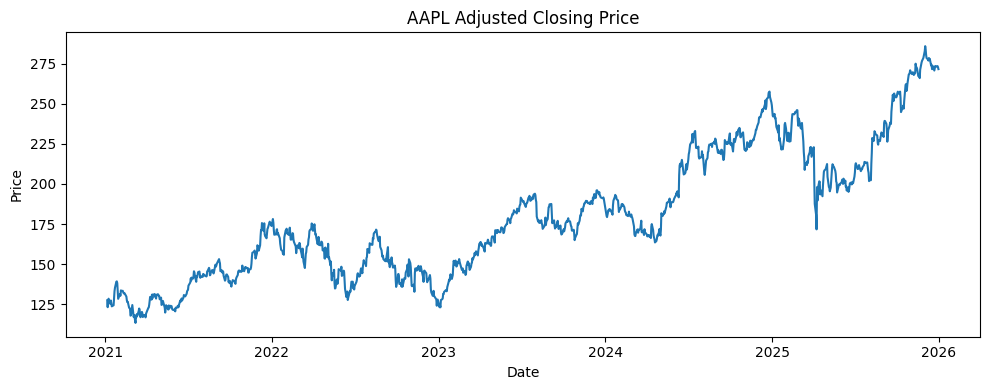

In [ ]:
# Plot adjusted closing price over time
plt.figure(figsize=(10, 4))
plt.plot(df.index, df['adj_close'])
plt.title(f"{ticker} Adjusted Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

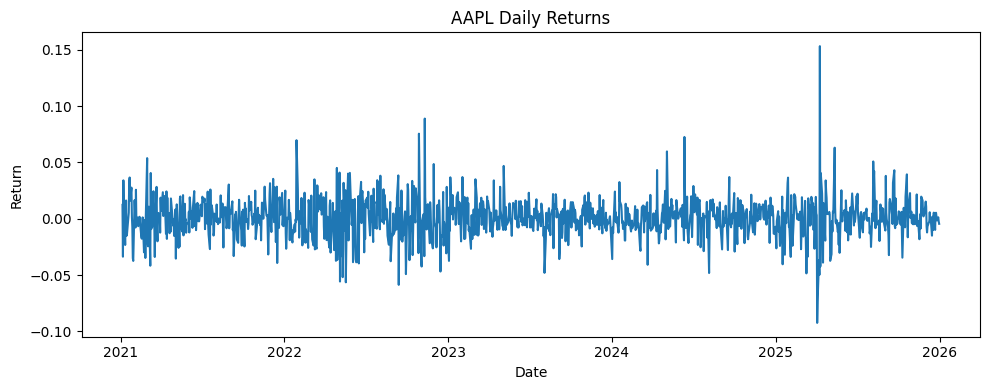

In [ ]:
# Plot daily returns over time to visualize volatility
plt.figure(figsize=(10, 4))
plt.plot(df.index, df['daily_return'])
plt.title(f"{ticker} Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.tight_layout()
plt.show()

In [ ]:
# Split data into 80% training and 20% testing
split_idx = int(len(df) * 0.8)

# Extract training and test sets from daily returns
train = df['daily_return'].iloc[:split_idx]
test = df['daily_return'].iloc[split_idx:]

# Display sizes of each set
print("Train size:", len(train))
print("Test size:", len(test))

Train size: 1003
Test size: 251


In [ ]:
# Build ARIMA model: order=(2,0,2) means AR(2), no differencing, MA(2)
model = ARIMA(train, order=(2, 0, 2))
# Fit the model to training data
model_fit = model.fit()

# Display model summary with statistics
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:           daily_return   No. Observations:                 1003
Model:                 ARIMA(2, 0, 2)   Log Likelihood                2680.239
Date:                Mon, 16 Mar 2026   AIC                          -5348.478
Time:                        21:30:07   BIC                          -5319.014
Sample:                             0   HQIC                         -5337.281
                               - 1003                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0008      0.001      1.622      0.105      -0.000       0.002
ar.L1          0.3543      0.471      0.753      0.452      -0.568       1.277
ar.L2         -0.2993      0.437     -0.686      0.4

/Users/samtouahri/anaconda3/envs/assignment8-stock/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/samtouahri/anaconda3/envs/assignment8-stock/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/samtouahri/anaconda3/envs/assignment8-stock/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
# Generate forecast for the test period length
forecast = model_fit.forecast(steps=len(test))
# Align forecast index with test set dates
forecast.index = test.index

# Display first few forecast values
forecast.head()

/Users/samtouahri/anaconda3/envs/assignment8-stock/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


Date
2024-12-31    0.001537
2025-01-02    0.001931
2025-01-03    0.001004
2025-01-06    0.000557
2025-01-07    0.000676
Name: predicted_mean, dtype: float64

In [ ]:
# Calculate Root Mean Squared Error - measures prediction error magnitude
rmse = np.sqrt(mean_squared_error(test, forecast))
# Calculate Mean Absolute Error - average absolute difference
mae = mean_absolute_error(test, forecast)

# Display performance metrics
print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")

RMSE: 0.020414
MAE:  0.012762


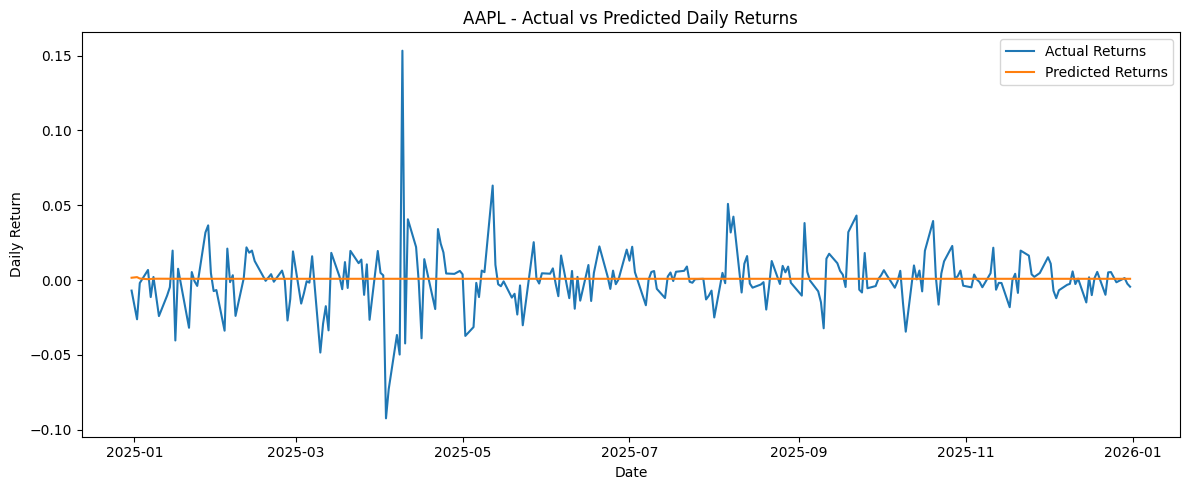

In [ ]:
# Visualize actual returns vs model predictions
plt.figure(figsize=(12, 5))
plt.plot(test.index, test.values, label="Actual Returns")
plt.plot(forecast.index, forecast.values, label="Predicted Returns")
plt.title(f"{ticker} - Actual vs Predicted Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Create a copy of test returns for financial analysis
test_returns = test.copy()

In [ ]:
# Calculate annualized return: compound daily returns to annual using 252 trading days
annual_return = (np.prod(1 + test_returns) ** (252 / len(test_returns))) - 1
print(f"Annual Return: {annual_return:.4f}")

Annual Return: 0.0832


In [ ]:
# Calculate Sharpe Ratio: risk-adjusted return metric (assumes 0 risk-free rate)
# Higher values indicate better risk-adjusted returns
sharpe_ratio = (test_returns.mean() / test_returns.std()) * np.sqrt(252)
print(f"Sharpe Ratio: {sharpe_ratio:.4f}")

Sharpe Ratio: 0.4058


In [ ]:
# Calculate Sortino Ratio: risk-adjusted return focusing only on downside risk
# Filter returns to include only negative returns (losses)
downside_returns = test_returns[test_returns < 0]
# Calculate standard deviation of downside returns
downside_deviation = downside_returns.std()

# Sortino Ratio: mean return / downside deviation, annualized
sortino_ratio = (test_returns.mean() / downside_deviation) * np.sqrt(252)
print(f"Sortino Ratio: {sortino_ratio:.4f}")

Sortino Ratio: 0.5571


In [ ]:
# Compile all performance metrics into a summary DataFrame
results = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "Annual Return", "Sharpe Ratio", "Sortino Ratio"],
    "Value": [rmse, mae, annual_return, sharpe_ratio, sortino_ratio]
})

# Display results table
results

,Metric,Value
0,RMSE,0.020414
1,MAE,0.012762
2,Annual Return,0.083173
3,Sharpe Ratio,0.405781
4,Sortino Ratio,0.557054


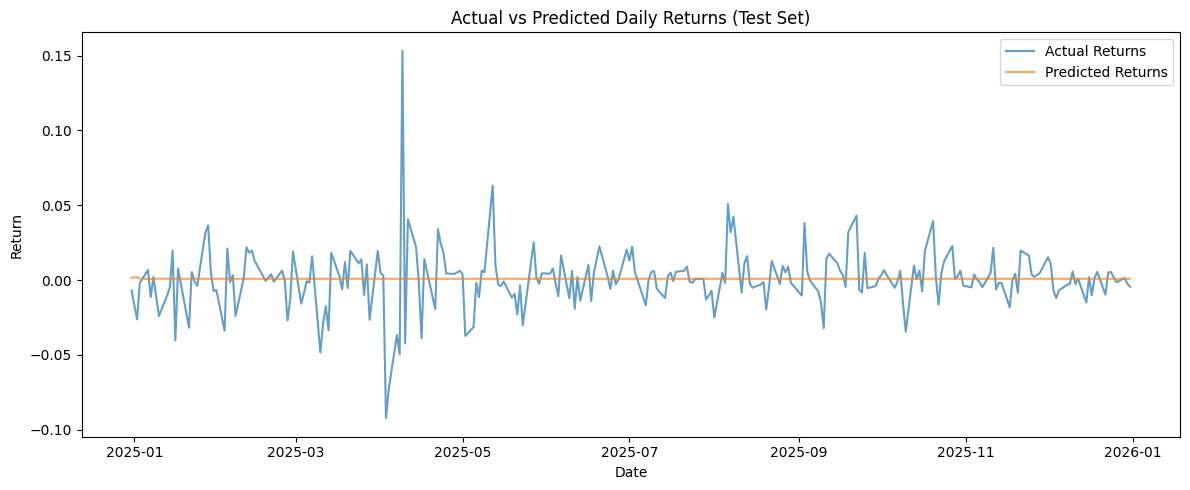

In [ ]:
# Plot actual vs predicted returns with transparency for clarity
plt.figure(figsize=(12,5))
plt.plot(test.index, test, label="Actual Returns", alpha=0.7)
plt.plot(forecast.index, forecast, label="Predicted Returns", alpha=0.7)
plt.title("Actual vs Predicted Daily Returns (Test Set)")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.tight_layout()
plt.show()

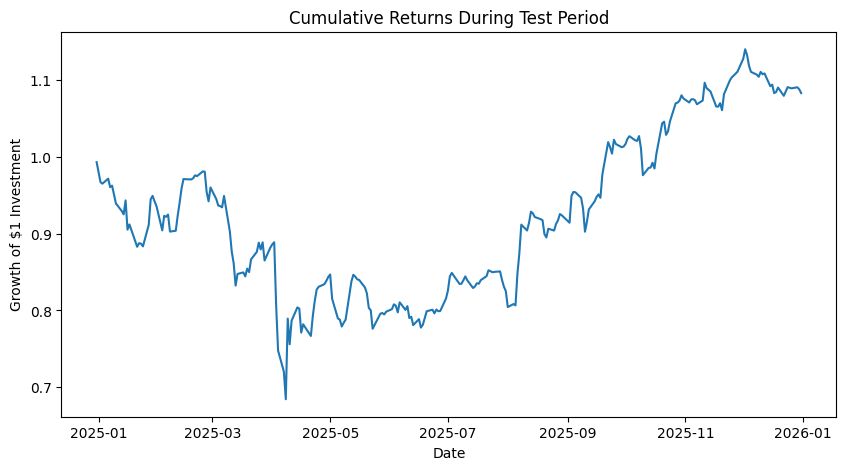

In [ ]:
# Calculate cumulative returns: shows how $1 invested grows over the test period
cum_returns = (1 + test).cumprod()

# Visualize cumulative returns growth
plt.figure(figsize=(10,5))
plt.plot(cum_returns)
plt.title("Cumulative Returns During Test Period")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Investment")
plt.show()